# Analyse du Data Drift


- psycopg2 = pour lire la base NeonDB
- spicy.test = pour faire les tests statistiques (KS test)

In [ ]:
import pandas as pd
import numpy as np
import json
import os
import psycopg2
import matplotlib.pyplot as plt
from scipy import stats
from psycopg2.extras import RealDictCursor
from dotenv import load_dotenv

load_dotenv()

True

## chargement des données de référence

In [ ]:
# Données de référence sur lesquelles le modèle a été entraîné
ref_data = pd.read_csv('train_test/sample_train.csv')

# Toutes les colonnes numériques communes aux deux datasets
FEATURES_TO_MONITOR = [
    col for col in ref_data.select_dtypes(include='number').columns
    if col not in ['SK_ID_CURR', 'TARGET']
]

print(f'dataframe de référence : {ref_data.shape}')

dataframe de référence : (61502, 261)


## chargement des données de production (depuis NeonDB)

- On récupère les prédictions loggées en production = chaque ligne contient les features du client qui a été scoré
- On va comparer ces données à celles de référence

In [ ]:
# données de production depuis NeonDB
conn = psycopg2.connect(os.getenv('NEON_DATABASE_URL'))
cur = conn.cursor(cursor_factory=RealDictCursor)
cur.execute("""
    SELECT input_features, prediction_proba, prediction
    FROM predictions
    WHERE status = 'success' AND input_features IS NOT NULL
""")
rows = cur.fetchall()
cur.close()
conn.close()

prod_data = pd.DataFrame([
    row['input_features'] if isinstance(row['input_features'], dict)
    else json.loads(row['input_features'])
    for row in rows
])
prod_data['prediction_proba'] = [row['prediction_proba'] for row in rows]
prod_data['prediction'] = [row['prediction'] for row in rows]
print(f'Données de prroduction: {prod_data.shape}')

Données de prroduction: (2551, 261)


## KS test par feature

On compare la distribution de chaque feature entre les données de référence et les données de prod

- KS test (Kolmogorov-Smirnov) retourne :
    - ks_statistic : écart maximal entre les deux distributions = plus c'est grand, plus elles sont différentes
    - p_value : si p inférieur à 0.05 on dit que l'écart est significatif et qu'il y a un drift

In [ ]:
DRIFT_THRESHOLD = 0.05 # seuil de la p value
results = []

for col in FEATURES_TO_MONITOR:
    if col not in prod_data.columns:
        continue
    ref_col  = ref_data[col].dropna()
    prod_col = prod_data[col].dropna()
    if len(prod_col) == 0:
        continue
    stat, p_value = stats.ks_2samp(ref_col, prod_col)
    results.append({
        'feature' : col,
        'ks_statistic' : round(stat, 4),
        'p_value': round(p_value, 4),
        'drift_detected' : p_value < DRIFT_THRESHOLD,
        'ref_mean': round(ref_col.mean(), 2),
        'prod_mean' : round(prod_col.mean(), 2),
    })

drift_df = pd.DataFrame(results).sort_values('drift_detected', ascending=False)
print(drift_df.to_string(index=False))
print(f"\n{drift_df['drift_detected'].sum()}/{len(drift_df)} features en drift")

                             feature  ks_statistic  p_value  drift_detected  ref_mean  prod_mean
                  NAME_CONTRACT_TYPE        0.0070   0.9997           False      0.10       0.09
 prev_DAYS_LAST_DUE_1ST_VERSION_mean        0.0059   1.0000           False      0.48       0.48
            prev_AMT_GOODS_PRICE_sum        0.0153   0.6071           False      0.02       0.02
         prev_RATE_DOWN_PAYMENT_mean        0.0186   0.3601           False      0.08       0.08
          prev_RATE_DOWN_PAYMENT_sum        0.0233   0.1369           False      0.04       0.04
             prev_DAYS_DECISION_mean        0.0171   0.4663           False      0.69       0.69
              prev_DAYS_DECISION_sum        0.0209   0.2332           False      0.95       0.95
               prev_CNT_PAYMENT_mean        0.0158   0.5656           False      0.20       0.20
                prev_CNT_PAYMENT_sum        0.0074   0.9992           False      0.03       0.03
         prev_DAYS_FIRST_DRAWI

## Visualisation

In [ ]:
FEATURES_TO_MONITOR = [
    'AMT_CREDIT', 'AMT_ANNUITY',
    'CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
]
FEATURES_TO_MONITOR = [f for f in FEATURES_TO_MONITOR if f in ref_data.columns]

Bleu = référence
Rouge = production


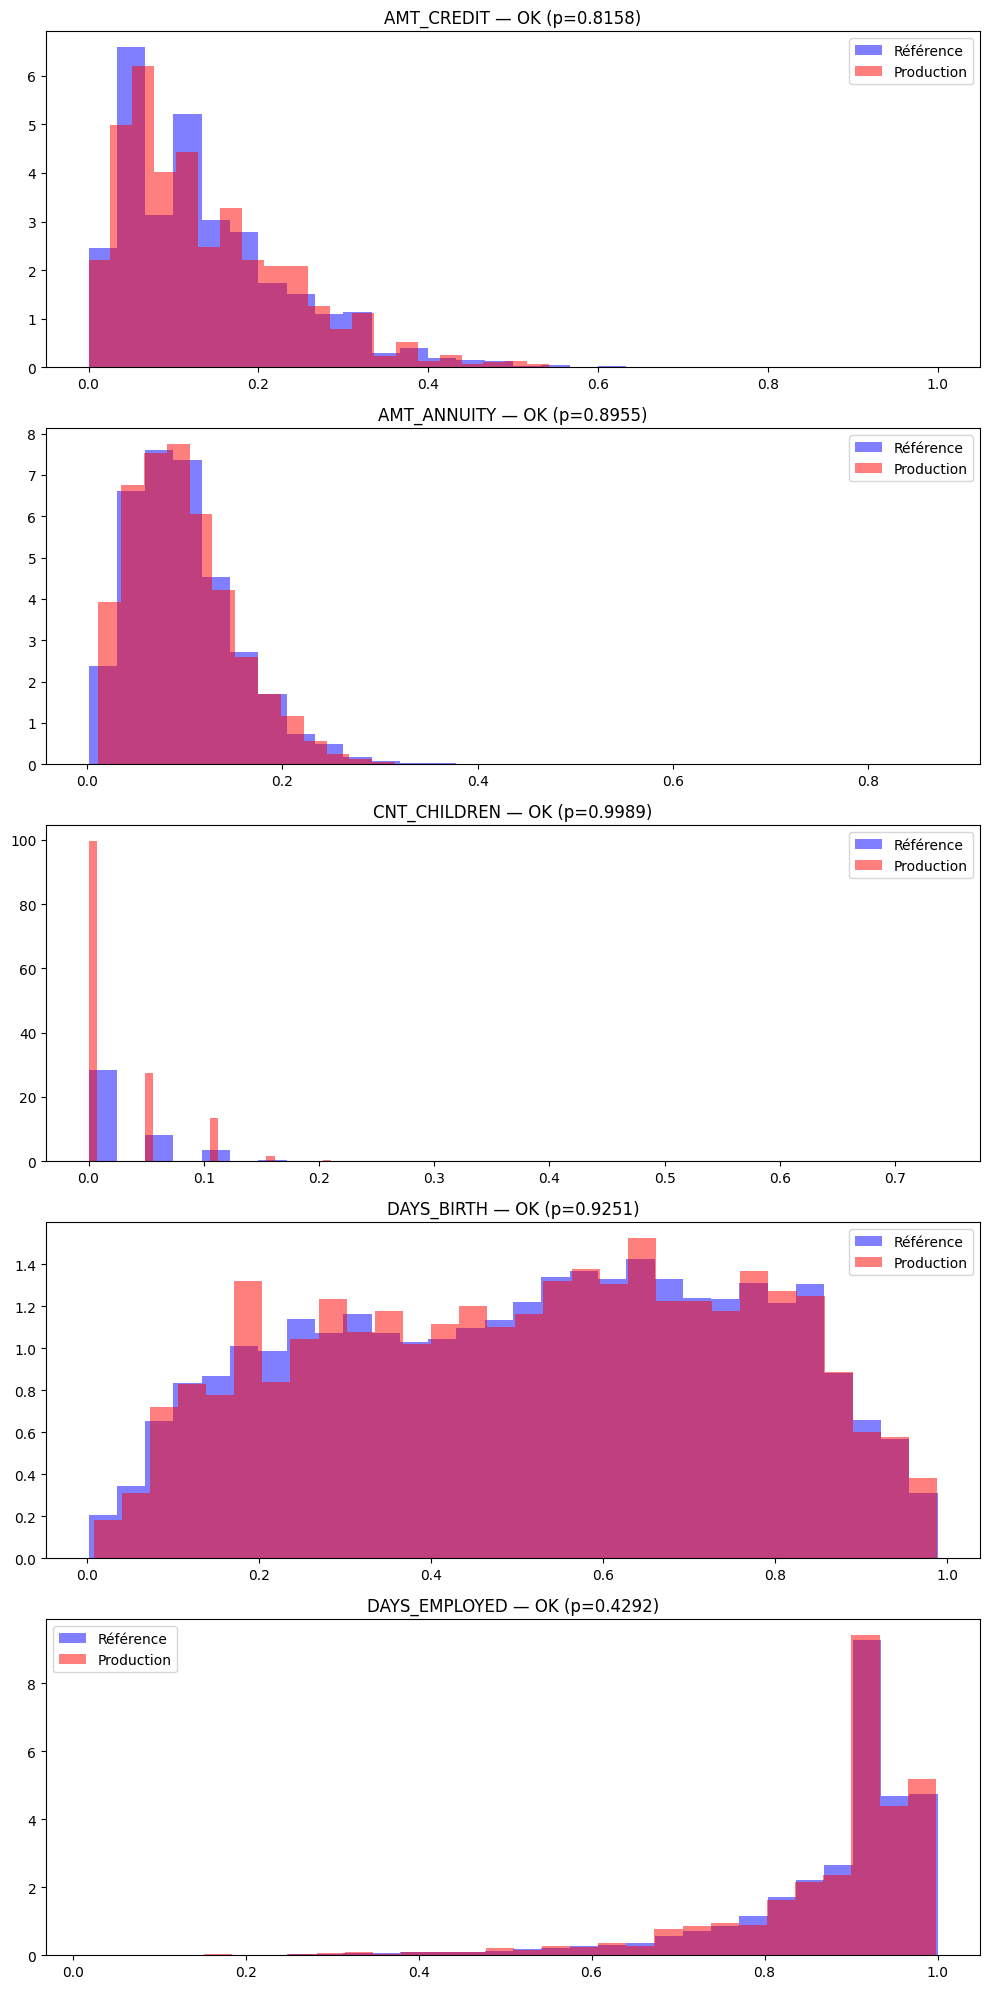

In [ ]:
fig, axes = plt.subplots(len(FEATURES_TO_MONITOR), 1, figsize=(10, 4 * len(FEATURES_TO_MONITOR)))
if len(FEATURES_TO_MONITOR) == 1:
    axes = [axes]

for ax, col in zip(axes, FEATURES_TO_MONITOR):
    if col not in prod_data.columns:
        continue
    ax.hist(ref_data[col].dropna(), bins=30, alpha=0.5, label='Référence', color='blue', density=True)
    ax.hist(prod_data[col].dropna(), bins=30, alpha=0.5, label='Production', color='red', density=True)
    row = drift_df[drift_df['feature'] == col]
    drift_flag = 'DRIFT' if row['drift_detected'].values[0] else 'OK'
    ax.set_title(f'{col} — {drift_flag} (p={row["p_value"].values[0]})')
    ax.legend()

plt.tight_layout()
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/data_drift_report.png')

print("Bleu = référence")
print ("Rouge = production")
plt.show()

## Scores de prédiction en référence et en production

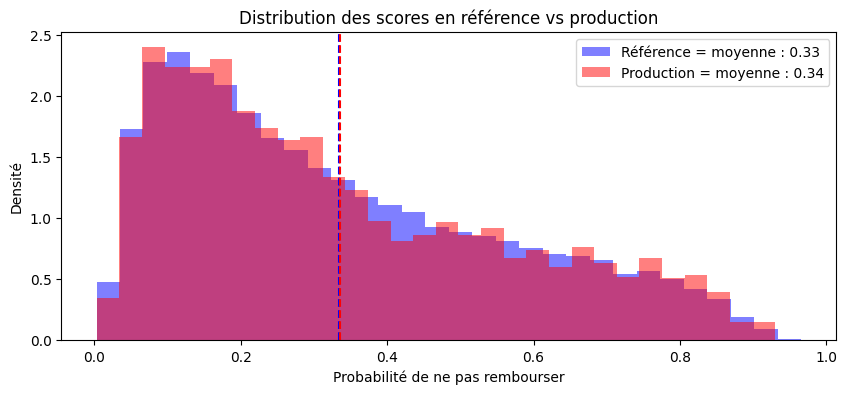

Score moyen référence : 0.334
Score moyen production: 0.335
Écart : 0.001


In [ ]:
import joblib
import re

model = joblib.load('model.pkl')
ref_clean = ref_data.copy()
ref_clean.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in ref_clean.columns]
feature_cols = [col for col in ref_clean.columns if col not in ['SK_ID_CURR', 'TARGET']]
ref_scores = model.predict_proba(ref_clean[feature_cols])[:, 1]

plt.figure(figsize=(10, 4))
plt.hist(ref_scores, bins=30, alpha=0.5, color='blue', density=True, label=f'Référence = moyenne : {ref_scores.mean():.2f}')
plt.hist(scores, bins=30, alpha=0.5, color='red', density=True, label=f'Production = moyenne : {scores.mean():.2f}')
plt.axvline(ref_scores.mean(), color='blue', linestyle='--')
plt.axvline(scores.mean(), color='red', linestyle='--')
plt.xlabel('Probabilité de ne pas rembourser')
plt.ylabel('Densité')
plt.title('Distribution des scores en référence vs production')
plt.legend()
plt.savefig('reports/score_distribution.png')
plt.show()

print(f'Score moyen référence : {ref_scores.mean():.3f}')
print(f'Score moyen production: {scores.mean():.3f}')
print(f'Écart: {abs(ref_scores.mean() - scores.mean()):.3f}')

## Résumé

**les résultats :**

- Aucun drift détecté = le modèle voit des données similaires à celles sur lesquelles il a été entraîné, les prédictions sont fiables
ça veut dire que le modèle voit en production le même type de clients que ceux sur lesquels il a appris : le modèle n'a pas besoin d'être réentraîné pour le moment

Actions possibles si drift détecté :
1. Analyser la cause du drift (changement de population, problème de données en amont)
2. évaluer l'impact sur les métriques business (coût métier)
3. Envisager un réentraînement avec des données récentes

In [ ]:
# Résumé final
print('=== RÉSUMÉ ANALYSE DATA DRIFT ===')
print(f'Features analysées    : {len(drift_df)}')
print(f'Features en drift     : {n_drifted}')
print(f'Taux de drift         : {n_drifted/len(drift_df)*100:.0f}%')

if n_drifted == 0:
    print('\n✅ Aucun drift détecté — modèle stable en production')
elif n_drifted <= 2:
    print('\n⚠️  Drift mineur détecté — surveillance à renforcer')
else:
    print('\n🔴 Drift significatif — réentraînement du modèle à envisager')

print('\nRapport complet : reports/data_drift_report.html')